In [1]:
%pip install xgboost pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model & evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("✅ Installation and Imports Completed!")

✅ Installation and Imports Completed!


## 2: Load Dataset

In [3]:
# Load processed dataset
df = pd.read_csv('../data/Processed/cleaned_dataset.csv')

# Separate features (X) and target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Convert boolean columns to integers (XGBoost requires this)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print("✅ Data Loaded Successfully")
print(f"Shape: {df.shape}")

✅ Data Loaded Successfully
Shape: (1470, 45)


## 3: Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintains class balance for the target variable
)

print("✅ Data Split Completed")

✅ Data Split Completed


## 4: Random Forest Model Training

In [5]:
# RANDOM FOREST CLASSIFIER (TUNED PARAMETERS)
rf_model = RandomForestClassifier(
    n_estimators=316,
    max_depth=25,
    min_samples_split=17,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("✅ Random Forest Model Trained")

✅ Random Forest Model Trained


## 5: XGBoost Model Training

In [6]:
# XGBOOST CLASSIFIER (TUNED PARAMETERS)
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    gamma=0.2,
    scale_pos_weight=5, # Crucial for handling imbalanced Attrition data
    eval_metric='logloss',
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

print("✅ XGBoost Model Trained")

✅ XGBoost Model Trained


## 6: Predictions

In [7]:
# MAKE PREDICTIONS

# Random Forest predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# XGBoost predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("✅ Predictions Completed")

✅ Predictions Completed


## 7: Evaluation Metrics Table

In [8]:
# EVALUATION METRICS TABLE
# ================================

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1-Score': [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

# Display the results rounded to 4 decimal places
print("📊 Performance Metrics Comparison:")
results.round(4)

📊 Performance Metrics Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8299,0.3636,0.0851,0.1379,0.7890
1,XGBoost,0.8197,0.4375,0.4468,0.4421,0.7796


## 8: Confusion Matrix

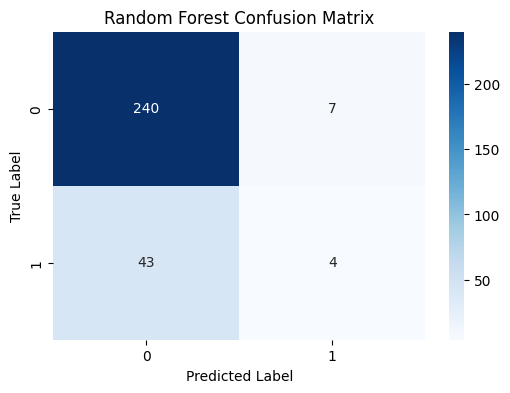

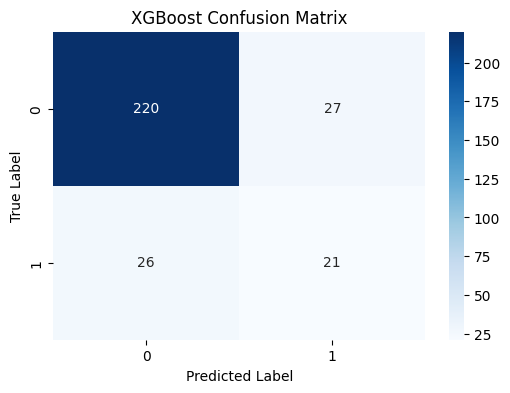

In [9]:
# VISUALIZATION: CONFUSION MATRIX

def plot_cm(y_true, y_pred, title):
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Plotting for both models to compare errors
plot_cm(y_test, rf_pred, "Random Forest Confusion Matrix")
plot_cm(y_test, xgb_pred, "XGBoost Confusion Matrix")

## 9: ROC Curve

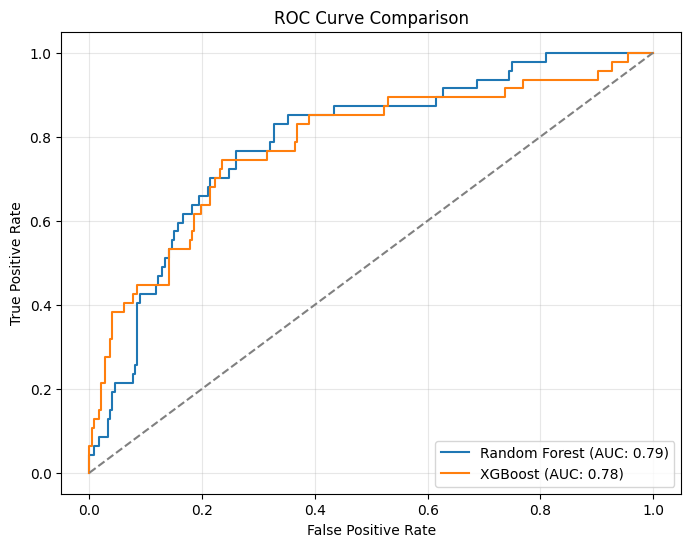

In [10]:
# VISUALIZATION: ROC CURVE COMPARISON

plt.figure(figsize=(8, 6))

# Calculate False Positive Rate and True Positive Rate
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# Plotting both curves
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC: {roc_auc_score(y_test, rf_prob):.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC: {roc_auc_score(y_test, xgb_prob):.2f})')

# Baseline diagonal line (Random guessing)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3) # Adds a light grid for better readability
plt.show()